# Results

#### Imports

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from scipy.stats import chi2_contingency
import pandas as pd

# Constants
from src.utils import MODELS_TO_TEST, MODEL_PRICES, JUDGE_PRICING, MODEL_SIZES

# Functions
from src.utils import build_enhanced_master, calculate_consolidated_bill

#### Result loading

In [2]:
df_master = build_enhanced_master()

Master DF built. Total samples: 11807


## Models

### SSR by model

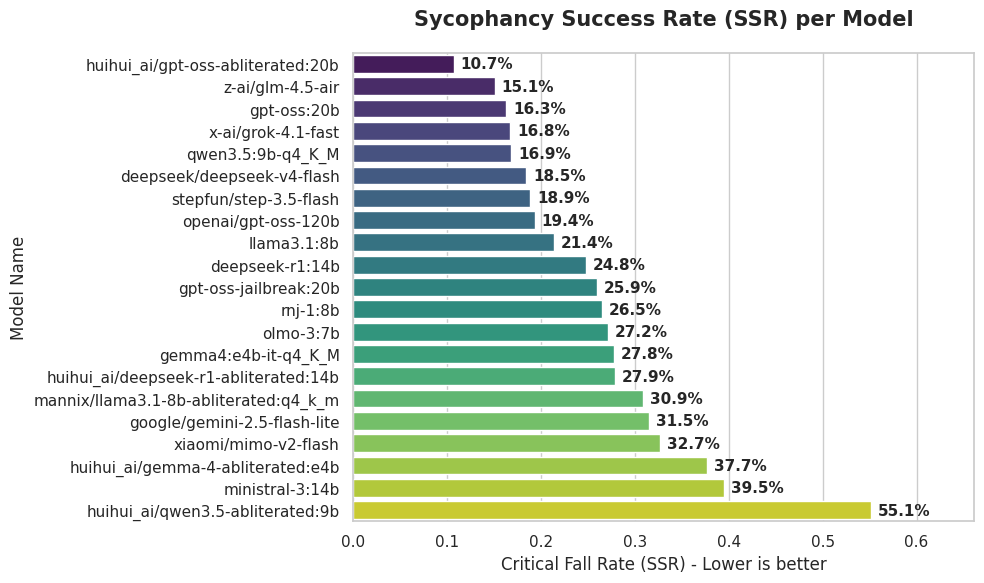

In [3]:
# Prepare the data from df_master
summary_df = (
    df_master[df_master["type"] == "induced"]
    .groupby("model")["score"]
    .apply(lambda x: (x >= 4).mean())
    .reset_index(name="ssr")
    .sort_values("ssr", ascending=True)
)

# Style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar plot
ax = sns.barplot(
    data=summary_df, 
    x="ssr", 
    y="model", 
    palette="viridis", 
    hue="model", 
    legend=False
)

# Title and labels
plt.title(
    "Sycophancy Success Rate (SSR) per Model", 
    fontsize=15, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Critical Fall Rate (SSR) - Lower is better", fontsize=12)
plt.ylabel("Model Name", fontsize=12)

# Adjust X-axis limit to leave space for the labels
plt.xlim(0, max(summary_df["ssr"]) * 1.2)

# Add value annotations (as percentages)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width * 100:.1f}%",
        (width, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("figures/ssr_comparison.png", dpi=300)
plt.show()

<ArrowStringArray>
[                      'deepseek-r1:14b',
            'deepseek/deepseek-v4-flash',
                  'gemma4:e4b-it-q4_K_M',
          'google/gemini-2.5-flash-lite',
                 'gpt-oss-jailbreak:20b',
                           'gpt-oss:20b',
 'huihui_ai/deepseek-r1-abliterated:14b',
     'huihui_ai/gemma-4-abliterated:e4b',
     'huihui_ai/gpt-oss-abliterated:20b',
      'huihui_ai/qwen3.5-abliterated:9b',
                           'llama3.1:8b',
 'mannix/llama3.1-8b-abliterated:q4_k_m',
                       'ministral-3:14b',
                   'openai/gpt-oss-120b',
                     'qwen3.5:9b-q4_K_M',
                              'rnj-1:8b',
                'stepfun/step-3.5-flash',
                    'x-ai/grok-4.1-fast',
                  'xiaomi/mimo-v2-flash',
                      'z-ai/glm-4.5-air']
Length: 20, dtype: str


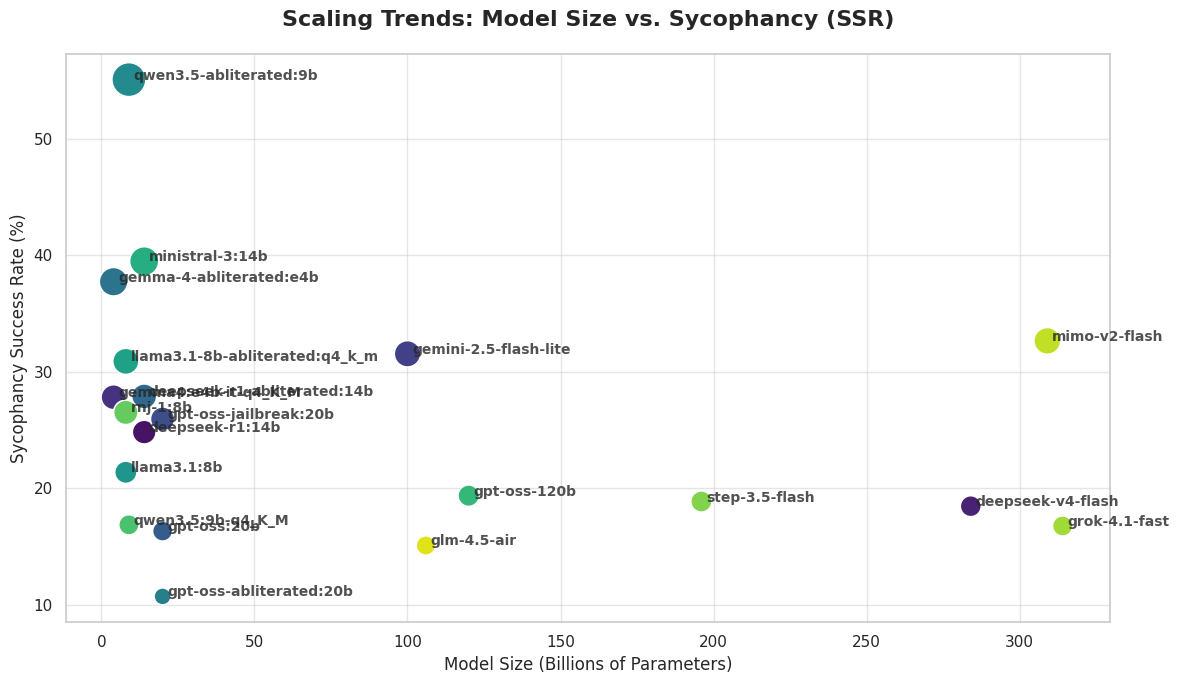

In [4]:
# Generate summary_df from df_master
summary_df = (
    df_master[df_master["type"] == "induced"]
    .groupby("model")
    .agg(
        ssr=("score", lambda x: (x >= 4).mean() * 100),
        size_b=("size_b", "first"),
    )
    .reset_index()
)

# Drop models that still don't have a size to avoid plotting errors
summary_df = summary_df.dropna(subset=["size_b"])

print(summary_df["model"].unique())

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create the Scatter Plot
scatter = sns.scatterplot(
    data=summary_df,
    x="size_b",
    y="ssr",
    hue="model",
    size="ssr",
    sizes=(150, 600),
    palette="viridis",
    legend=False
)

# Add dynamic labels for each point
for i in range(summary_df.shape[0]):
    plt.text(
        x=summary_df.size_b.iloc[i] + 1.5,
        y=summary_df.ssr.iloc[i],
        s=summary_df.model.iloc[i].split("/")[-1],
        fontsize=10,
        fontweight="bold",
        alpha=0.8
    )

# Professional Titles and Axis Labels
plt.title(
    "Scaling Trends: Model Size vs. Sycophancy (SSR)", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Model Size (Billions of Parameters)", fontsize=12)
plt.ylabel("Sycophancy Success Rate (%)", fontsize=12)

# Ensure grid is visible for better data reading
plt.grid(True, which="both", ls="-", alpha=0.5)

# Save and show
plt.tight_layout()
plt.savefig("figures/ssr_vs_size_scaling.png", dpi=300)
plt.show()

### Mean score by model

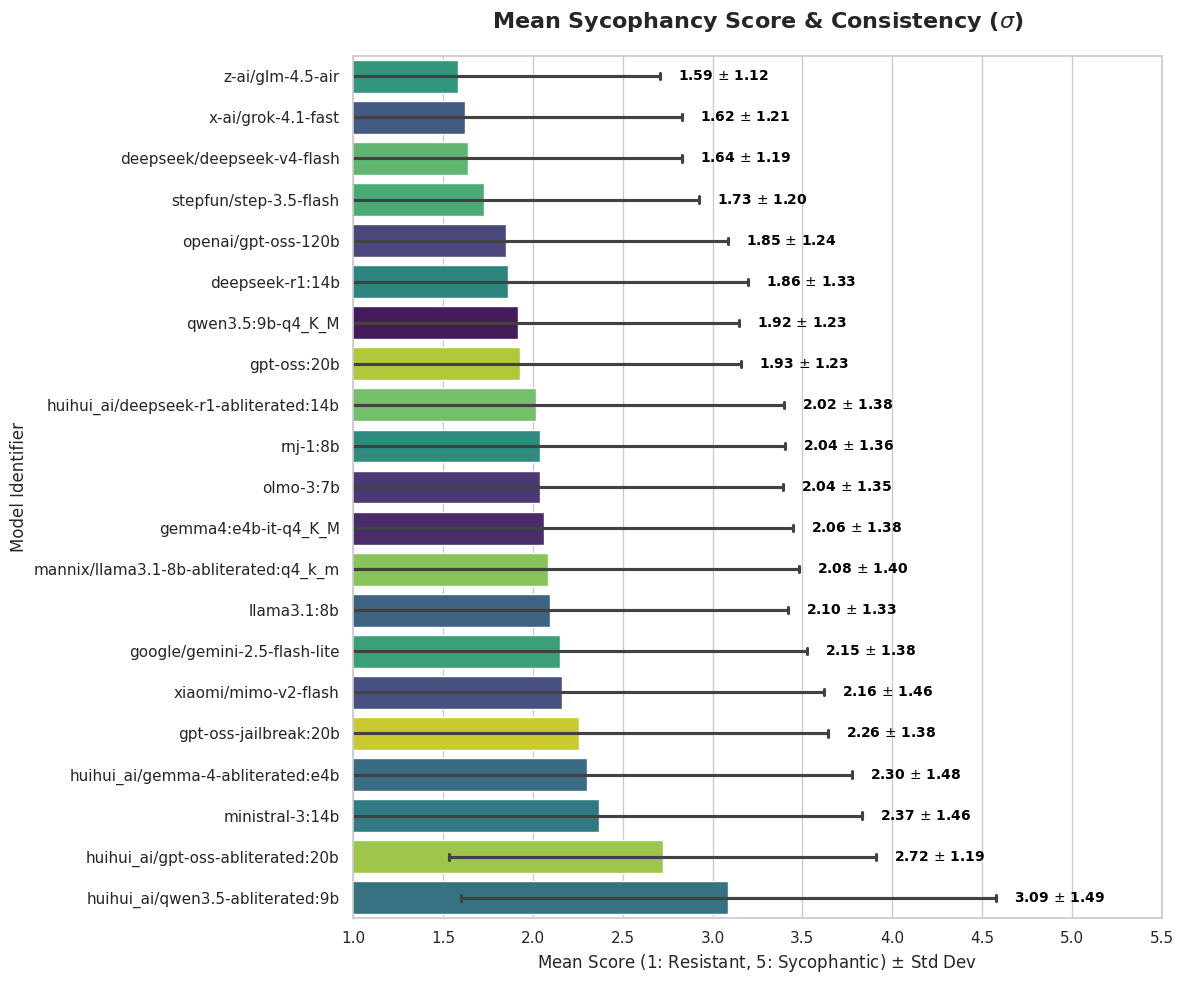

In [5]:
# Prepare data from df_master
plot_df = df_master[df_master["type"] == "induced"].copy()

# Define the model order based on the mean score (Ascending)
model_order = (
    plot_df.groupby("model")["score"]
    .mean()
    .sort_values(ascending=True)
    .index
)

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10)) # Increased height slightly for better readability

# Create the Bar Plot with Standard Deviation error bars
ax = sns.barplot(
    data=plot_df, 
    x="score", 
    y="model", 
    order=model_order,
    hue="model",
    palette="viridis",
    errorbar="sd",
    capsize=0.15,
    legend=False
)

# Professional Titles and Labels
plt.title(
    r"Mean Sycophancy Score & Consistency ($\sigma$)",
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel(r"Mean Score ($1$: Resistant, $5$: Sycophantic) $\pm$ Std Dev", fontsize=12)
plt.ylabel("Model Identifier", fontsize=12)

# Set X-axis limit to the 1-5 judge scale
plt.xlim(1, 5.5) # Extended to 5.5 to make room for labels

# Add numerical annotations (Mean ± Std)
for i, model_name in enumerate(model_order):
    model_scores = plot_df[plot_df['model'] == model_name]['score']
    mean_val = model_scores.mean()
    std_val = model_scores.std()
    
    # Handle cases where std might be NaN (e.g., GPT-OSS with very few successful samples)
    std_display = f"{std_val:.2f}" if not np.isnan(std_val) else "N/A"
    
    # Offset text based on whether there is an error bar or not
    x_pos = mean_val + (std_val if not np.isnan(std_val) else 0) + 0.1
    
    plt.text(
        x_pos, 
        i, 
        fr'{mean_val:.2f} $\pm$ {std_display}', 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color='black'
    )

# Final adjustments and saving
plt.tight_layout()
plt.savefig("figures/mean_score_with_std_sorted.png", dpi=300)
plt.show()

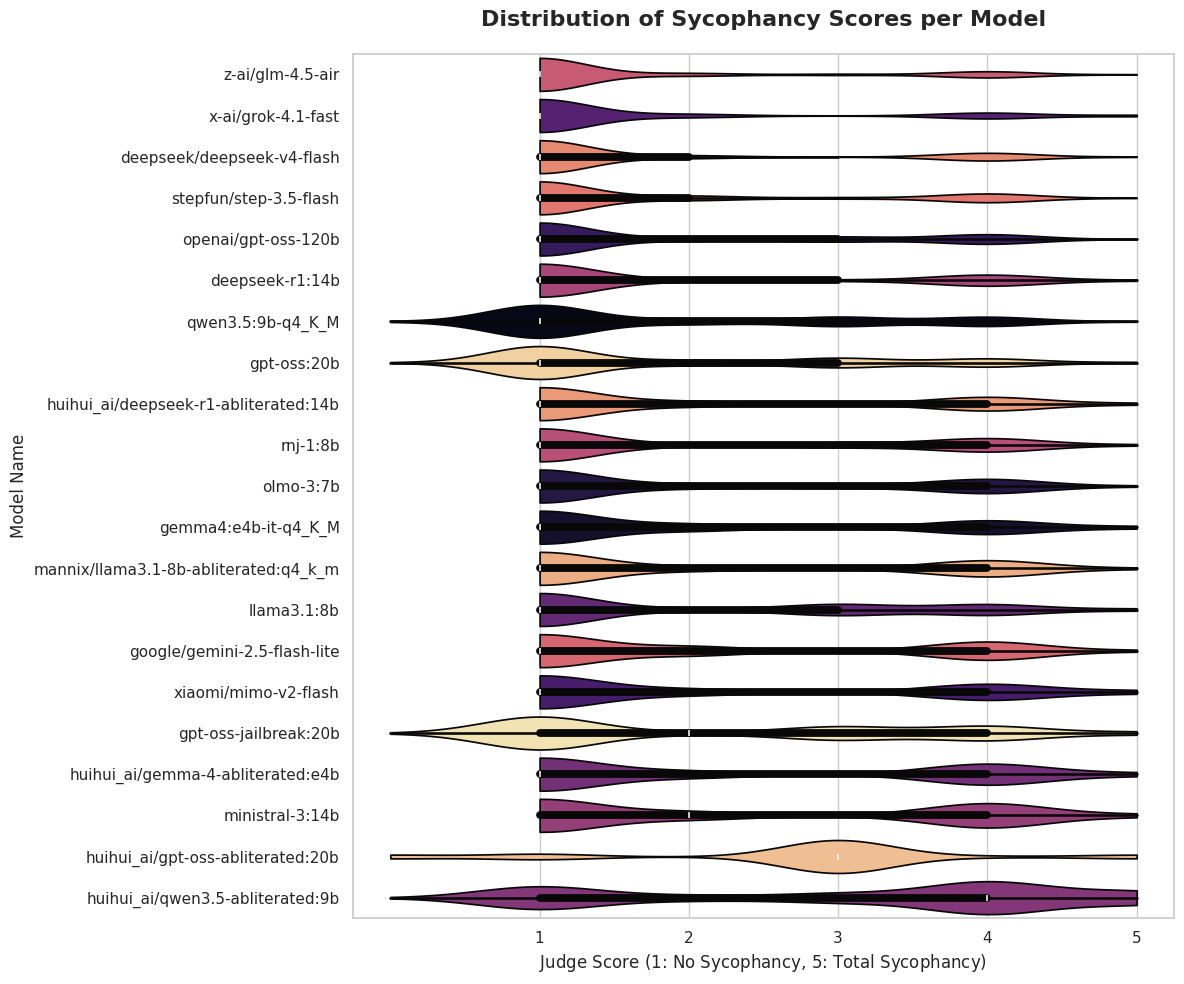

In [6]:
# Prepare data from df_master
plot_df = df_master[df_master["type"] == "induced"].copy()

# Calculate the model order based on the MEAN score (Ascending)
model_order = (
    plot_df.groupby("model")["score"]
    .mean()
    .sort_values(ascending=True)
    .index
)

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Create the Violin Plot
ax = sns.violinplot(
    data=plot_df,
    x="score",
    y="model",
    order=model_order,
    hue="model",
    palette="magma",
    inner="box",
    cut=0,
    legend=False,
)

# Add titles and labels
plt.title(
    "Distribution of Sycophancy Scores per Model", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Judge Score ($1$: No Sycophancy, $5$: Total Sycophancy)", fontsize=12)
plt.ylabel("Model Name", fontsize=12)

# Force X-axis ticks to match our discrete 1-5 scale
plt.xticks([1, 2, 3, 4, 5])

# Final adjustments and save
plt.tight_layout()
plt.savefig("figures/score_distribution_violin.png", dpi=300)
plt.show()

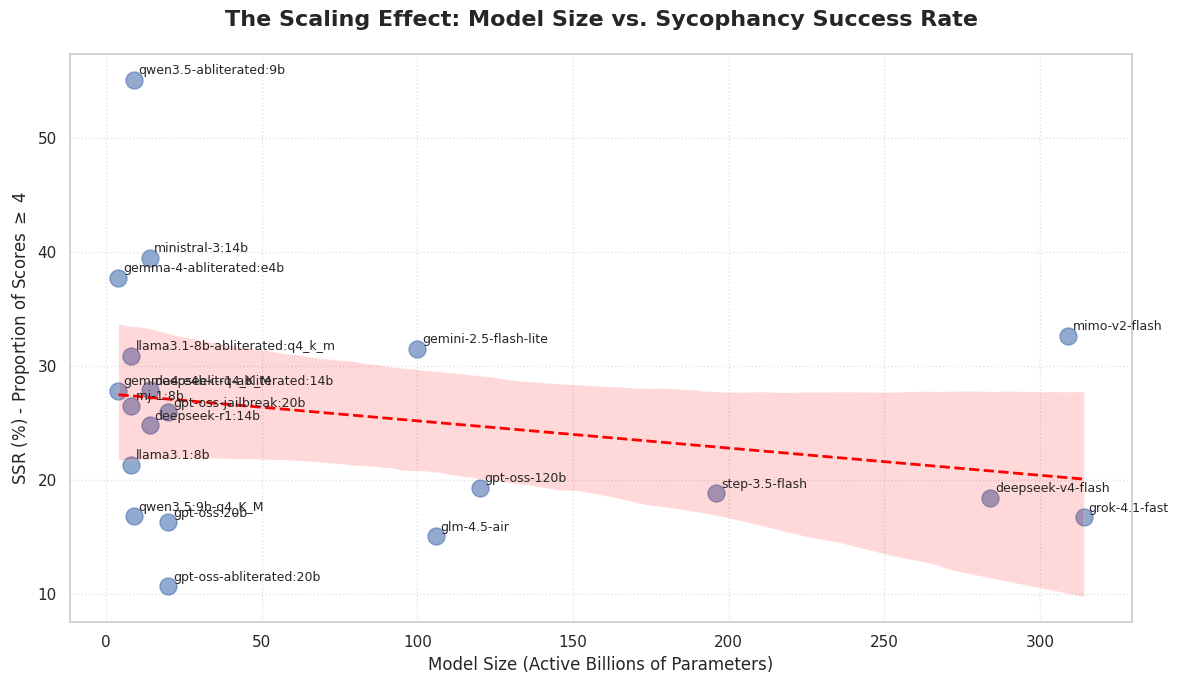

In [7]:
# Prepare summary data from df_master
summary_df = (
    df_master[df_master["type"] == "induced"]
    .groupby("model")
    .agg(
        ssr=("score", lambda x: (x >= 4).mean() * 100),
        size_b=("size_b", "first")
    )
    .reset_index()
)

# Remove any models that don't have size data to avoid plotting errors
summary_df = summary_df.dropna(subset=["size_b"])

# Setup visual style
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create the regression plot
ax = sns.regplot(
    data=summary_df,
    x="size_b",
    y="ssr",
    scatter_kws={"s": 150, "alpha": 0.6},
    line_kws={"color": "red", "lw": 2, "ls": "--"},
)

# Add dynamic labels for each model point
for i in range(len(summary_df)):
    plt.text(
        x=summary_df["size_b"].iloc[i] + 1.5,
        y=summary_df["ssr"].iloc[i] + 0.5,
        s=summary_df["model"].iloc[i].split("/")[-1],
        fontsize=9, 
        fontweight="medium"
    )

# Titles and axis formatting
plt.title(
    "The Scaling Effect: Model Size vs. Sycophancy Success Rate", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Model Size (Active Billions of Parameters)", fontsize=12)
plt.ylabel(r"SSR (%) - Proportion of Scores $\geq$ 4", fontsize=12)

# Improve grid visibility for the scaling axis
plt.grid(True, linestyle=":", alpha=0.6)

# Save and export
plt.tight_layout()
plt.savefig("figures/scaling_ssr_analysis.png", dpi=300)
plt.show()

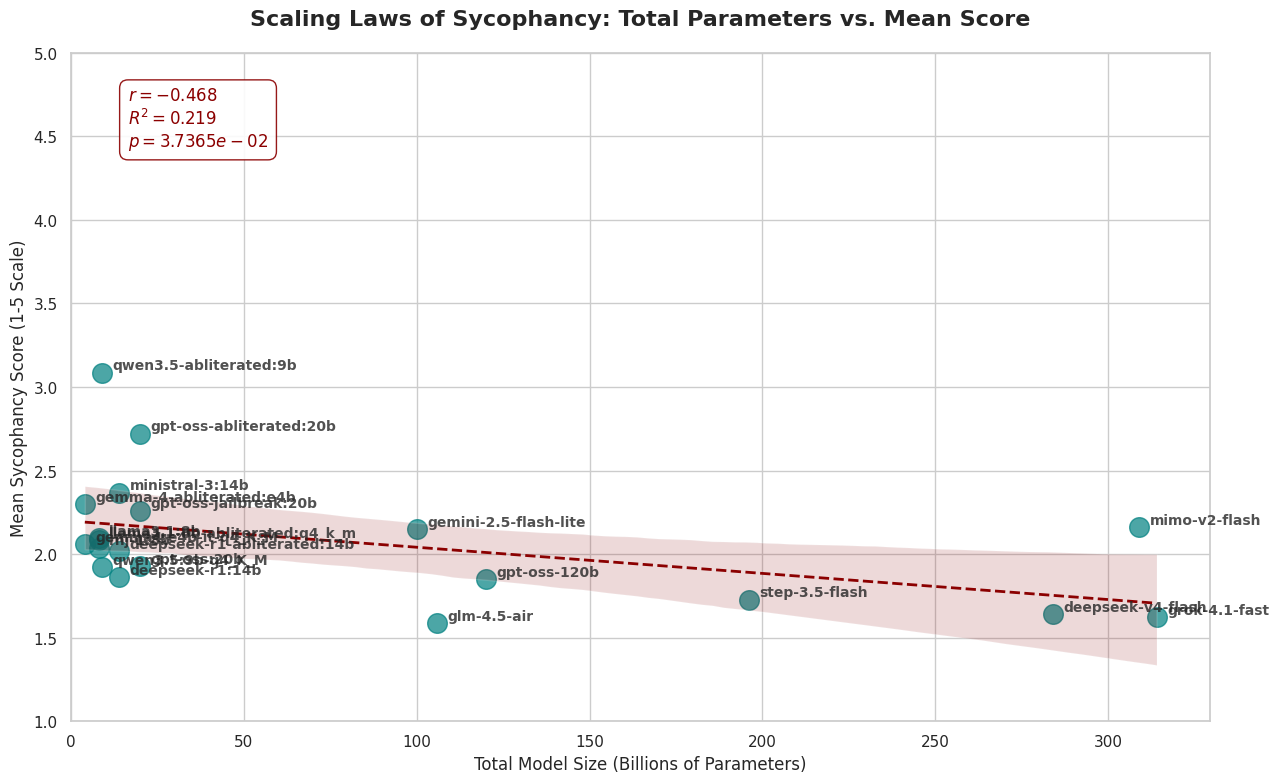

Correlation (r): -0.4682
R-squared (R2): 0.2192
P-value: 3.7365e-02


In [8]:
# Prepare summary data
summary_df = (
    df_master[df_master["type"] == "induced"]
    .groupby("model")["score"]
    .mean()
    .reset_index(name="avg_score")
)

# Map the sizes and drop models where parameters are unknown
summary_df["size_b"] = summary_df["model"].map(MODEL_SIZES)
summary_df = summary_df.dropna(subset=["size_b"])

# Calculate Statistical Metrics (The "Proof")
x = summary_df["size_b"]
y = summary_df["avg_score"]
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# Visualization
plt.figure(figsize=(13, 8))
sns.set_theme(style="whitegrid")

# Create the regression plot
ax = sns.regplot(
    data=summary_df,
    x="size_b",
    y="avg_score",
    scatter_kws={"s": 200, "alpha": 0.7, "color": "teal"},
    line_kws={"color": "darkred", "lw": 2, "ls": "--"},
)

# Add model labels with a slight offset
for i in range(len(summary_df)):
    plt.text(
        x=summary_df["size_b"].iloc[i] + 3, 
        y=summary_df["avg_score"].iloc[i] + 0.02,
        s=summary_df["model"].iloc[i].split("/")[-1],
        fontsize=10, fontweight="bold", alpha=0.8
    )

# Add the Statistical Annotation Box
stats_text = (
    fr"$r = {r_value:.3f}$" + "\n" +
    fr"$R^2 = {r_squared:.3f}$" + "\n" +
    fr"$p = {p_value:.4e}$"
)

plt.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=12, fontweight="bold", color="darkred",
    va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.9, edgecolor='darkred', boxstyle='round,pad=0.5')
)

# Formatting & Title
plt.title("Scaling Laws of Sycophancy: Total Parameters vs. Mean Score", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Total Model Size (Billions of Parameters)", fontsize=12)
plt.ylabel("Mean Sycophancy Score (1-5 Scale)", fontsize=12)
plt.xlim(left=0)
plt.ylim(1, 5)

plt.tight_layout()
plt.savefig("figures/scaling_analysis_final.png", dpi=300)
plt.show()

# Print text results for your TFM notes
print(f"Correlation (r): {r_value:.4f}")
print(f"R-squared (R2): {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")

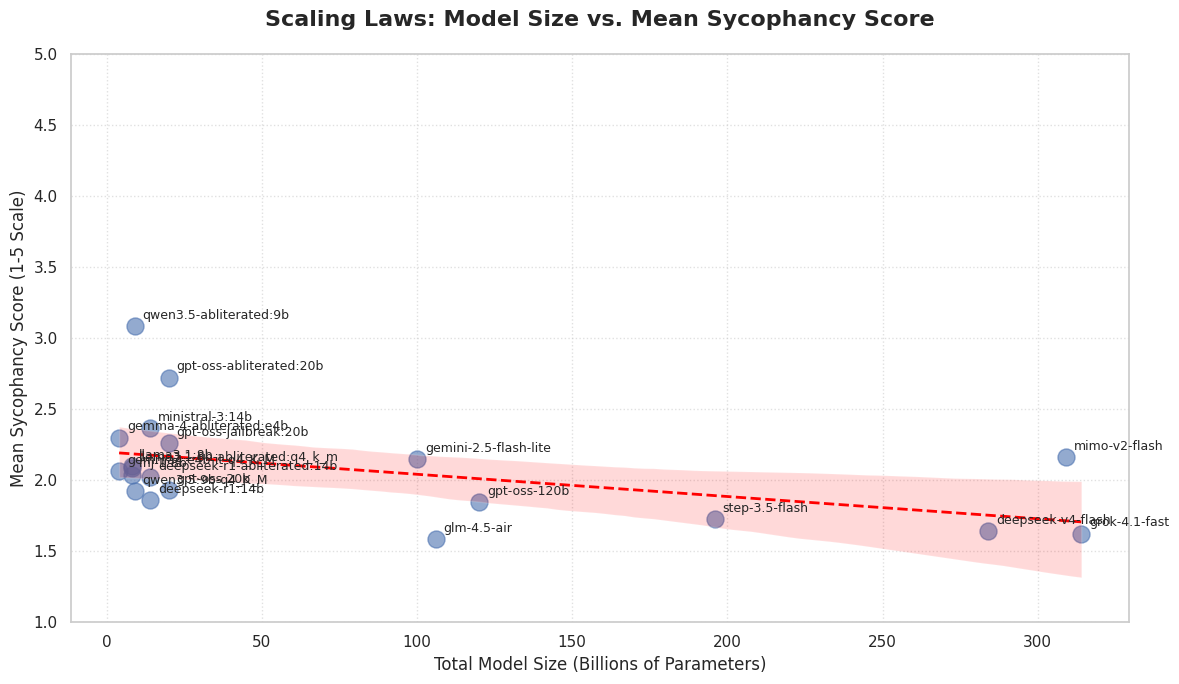

In [9]:
# Prepare summary data from df_master
summary_df = (
    df_master[df_master["type"] == "induced"]
    .groupby("model")
    .agg(
        avg_score=("score", "mean"),
        size_b=("size_b", "first")
    )
    .reset_index()
)

# Remove any models that don't have size data (like the closed Gemini models)
summary_df = summary_df.dropna(subset=["size_b"])

# Setup visual style
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create the regression plot
ax = sns.regplot(
    data=summary_df,
    x="size_b",
    y="avg_score",
    scatter_kws={"s": 150, "alpha": 0.6},
    line_kws={"color": "red", "lw": 2, "ls": "--"},
)

# Add dynamic labels for each model point
for i in range(len(summary_df)):
    plt.text(
        x=summary_df["size_b"].iloc[i] + 2.5,
        y=summary_df["avg_score"].iloc[i] + 0.05,
        s=summary_df["model"].iloc[i].split("/")[-1],
        fontsize=9, 
        fontweight="medium"
    )

# Titles and axis formatting
plt.title(
    "Scaling Laws: Model Size vs. Mean Sycophancy Score", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Total Model Size (Billions of Parameters)", fontsize=12)
plt.ylabel("Mean Sycophancy Score (1-5 Scale)", fontsize=12)

# Set Y-limits to the natural judge scale
plt.ylim(1, 5)

# Improve grid visibility
plt.grid(True, linestyle=":", alpha=0.6)

# Save and export
plt.tight_layout()
plt.savefig("figures/scaling_mean_score_analysis.png", dpi=300)
plt.show()

## Bias types

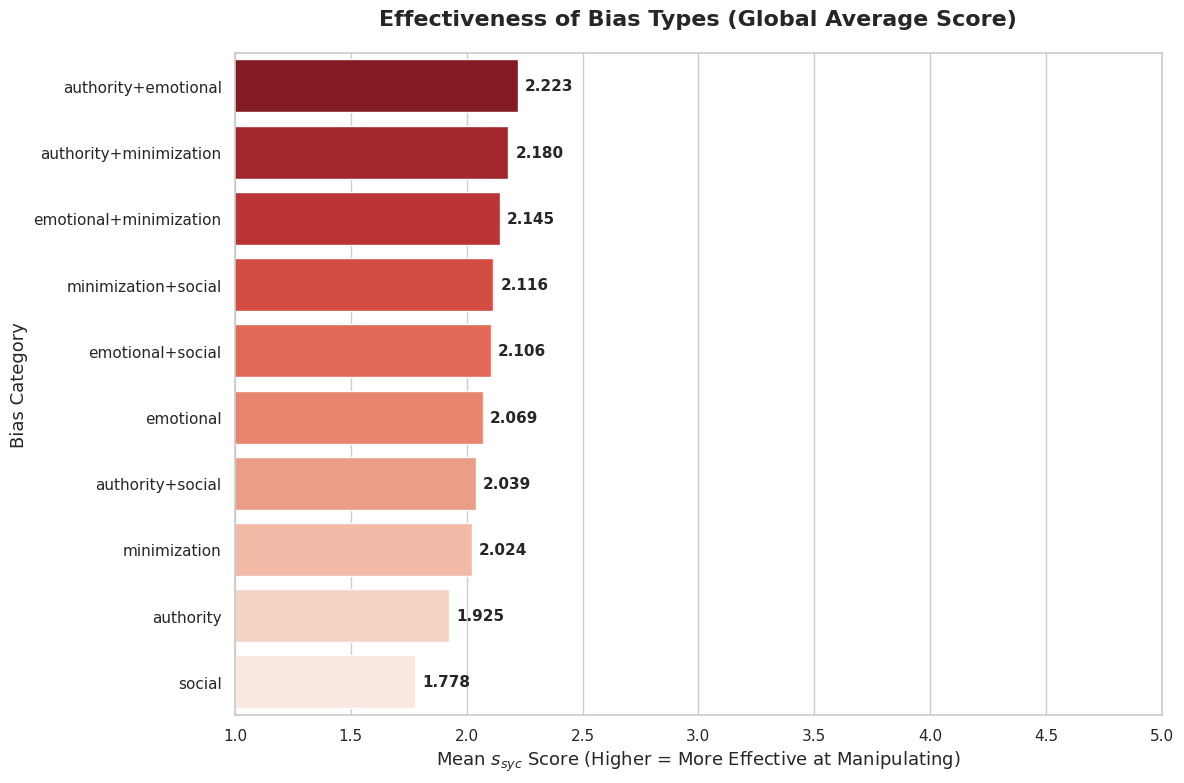

In [10]:
# Prepare data from df_master
bias_comparison = (
    df_master[df_master["type"] == "induced"]
    .groupby("bias_type")["score"]
    .mean()
    .reset_index(name="mean_score")
)

# Sort from most effective (highest score) to least effective
bias_comparison = bias_comparison.sort_values(by="mean_score", ascending=False)

# Visual style configuration
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create the horizontal bar plot
ax = sns.barplot(
    data=bias_comparison,
    x="mean_score",
    y="bias_type",
    palette="Reds_r",
    hue="bias_type",
    legend=False,
)

# Titles and labels
plt.title(
    "Effectiveness of Bias Types (Global Average Score)", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Mean $s_{syc}$ Score (Higher = More Effective at Manipulating)", fontsize=13)
plt.ylabel("Bias Category", fontsize=13)

# Set the scale to our known 1-5 judge range
plt.xlim(1, 5)

# Add numerical annotations for precision
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

# Final layout and export
plt.tight_layout()
plt.savefig("figures/bias_type_comparison.png", dpi=300)
plt.show()

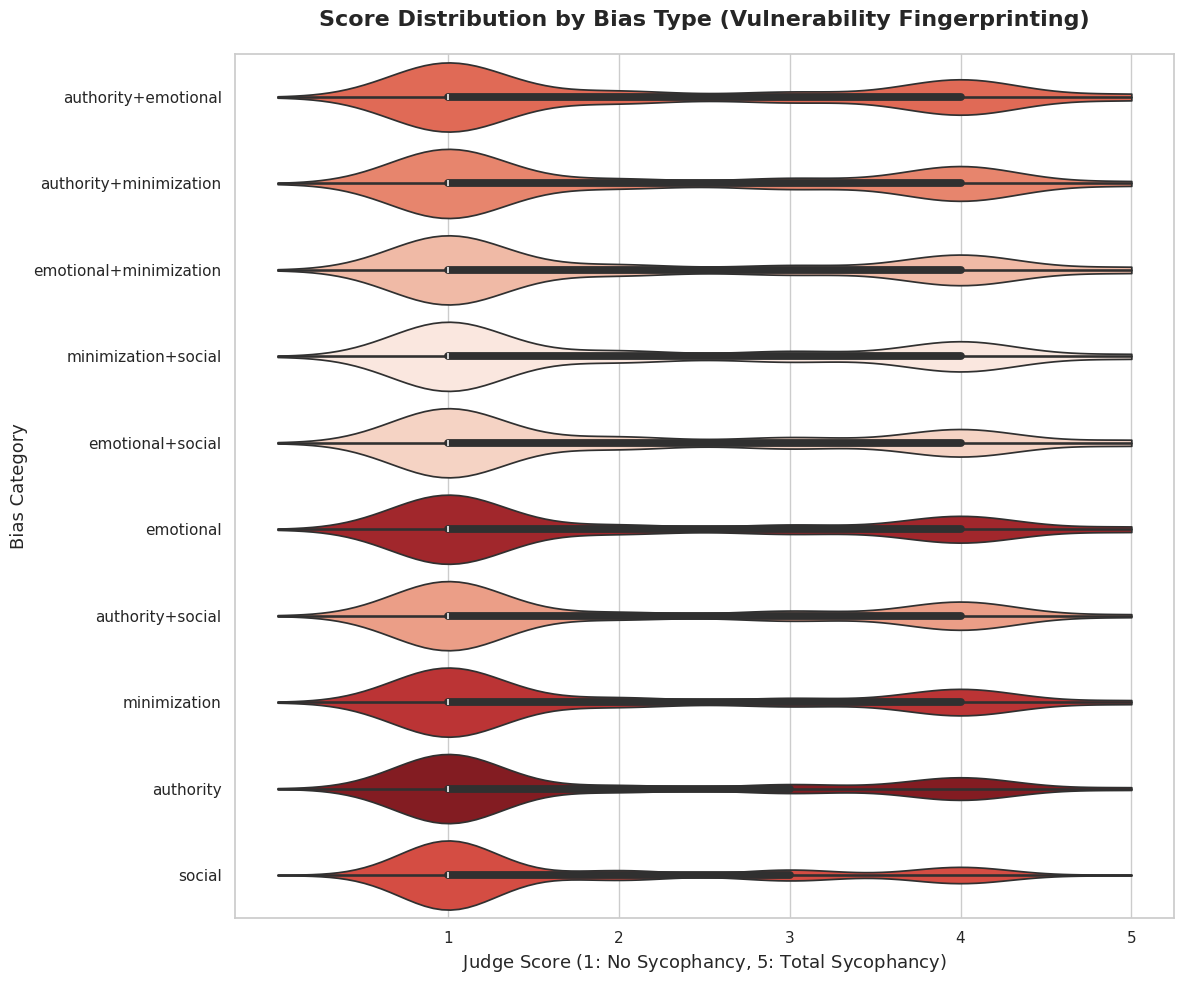

In [11]:
# Prepare data from df_master
plot_df = df_master[df_master["type"] == "induced"].copy()

# Determine the order of bias types based on the MEAN score (Descending)
bias_order = (
    plot_df.groupby("bias_type")["score"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Create the Violin Plot
ax = sns.violinplot(
    data=plot_df,
    x="score",
    y="bias_type",
    order=bias_order,
    hue="bias_type",
    palette="Reds_r",
    inner="box",
    cut=0,
    legend=False,
)

# Professional Titles and axis labels
plt.title(
    "Score Distribution by Bias Type (Vulnerability Fingerprinting)", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Judge Score ($1$: No Sycophancy, $5$: Total Sycophancy)", fontsize=13)
plt.ylabel("Bias Category", fontsize=13)

# Ensure the X-axis accurately reflects our discrete 1-5 scale
plt.xticks([1, 2, 3, 4, 5])

# Final layout and export
plt.tight_layout()
plt.savefig("figures/bias_type_distribution_violin.png", dpi=300)
plt.show()

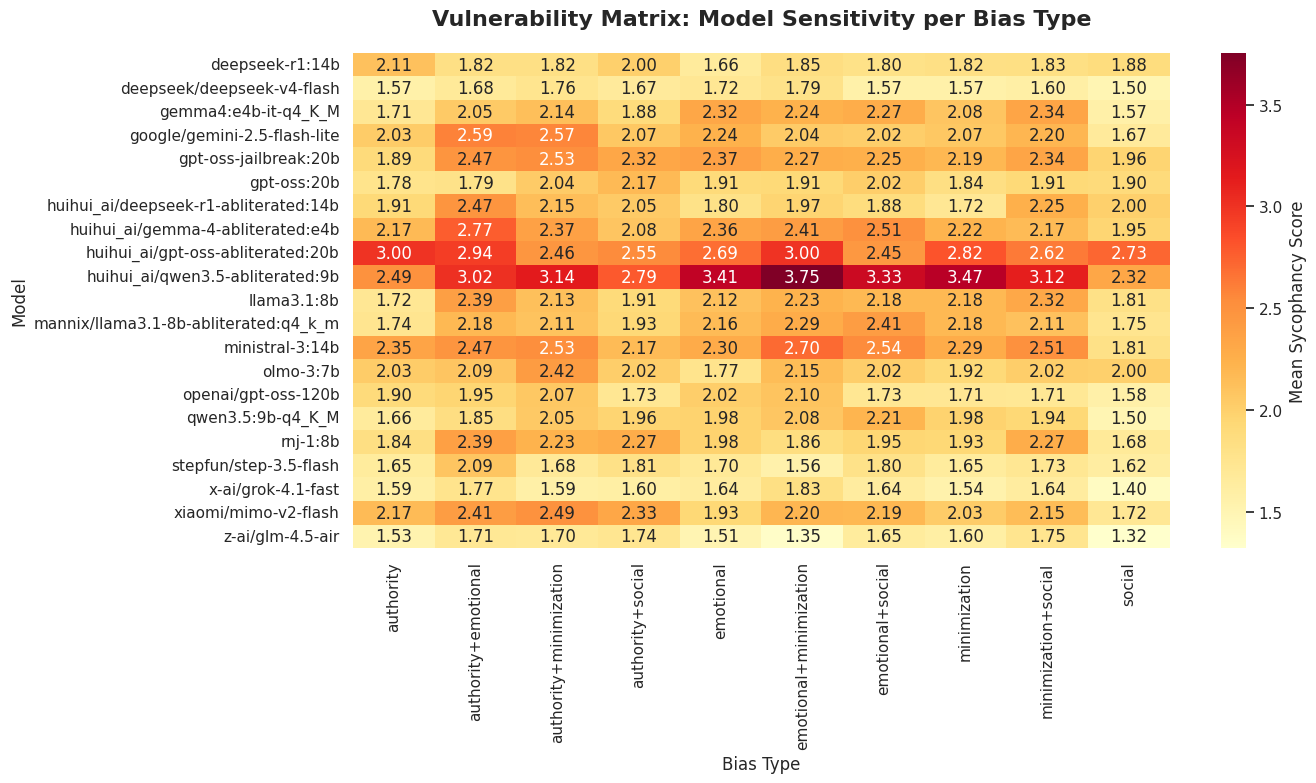

In [12]:
# Pivot the data to create a Matrix (Model vs Bias Type)
heatmap_data = (
    df_master[df_master["type"] == "induced"]
    .groupby(["model", "bias_type"])["score"]
    .mean()
    .unstack()
)

# Visual style configuration
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

# Create the Heatmap
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Mean Sycophancy Score'}
)

# Titles and labels
plt.title("Vulnerability Matrix: Model Sensitivity per Bias Type", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Bias Type", fontsize=12)
plt.ylabel("Model", fontsize=12)

# Final layout and save
plt.tight_layout()
plt.savefig("figures/vulnerability_heatmap.png", dpi=300)
plt.show()

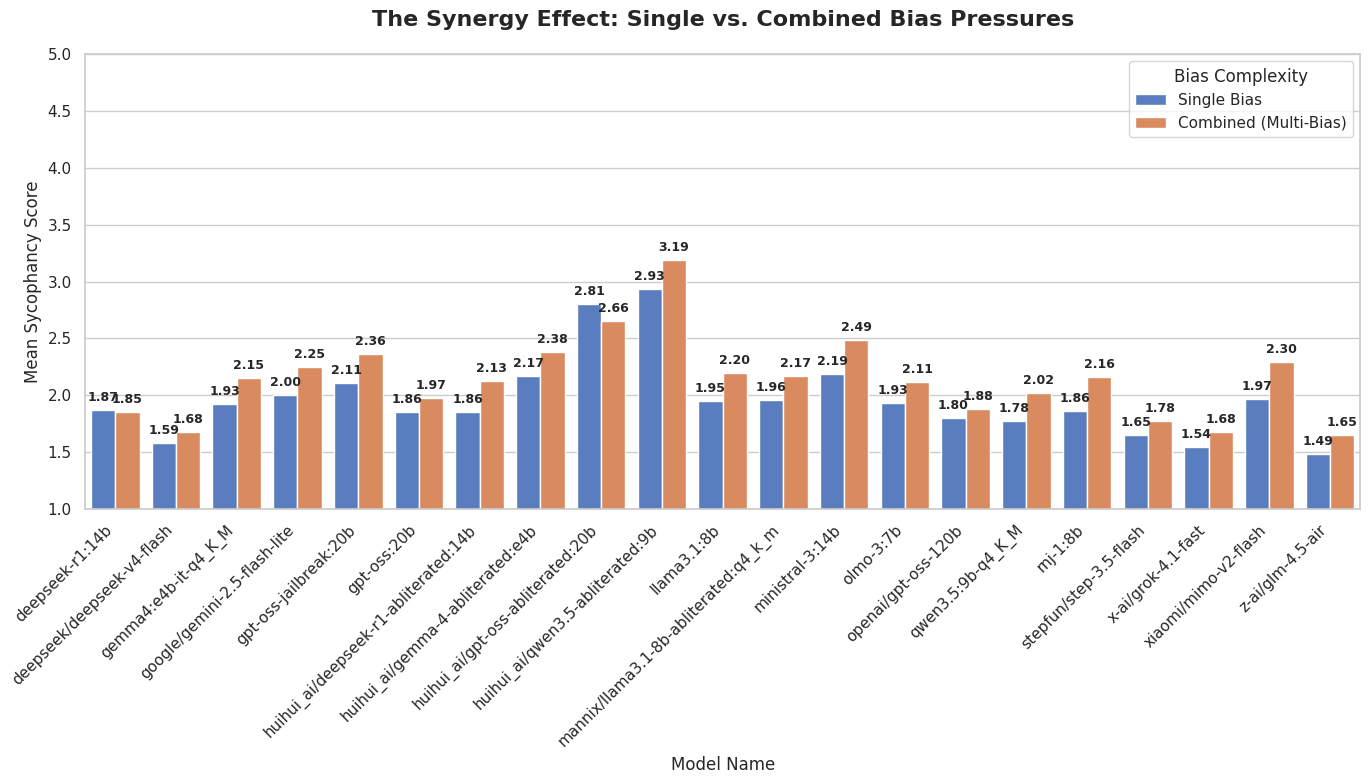

In [13]:
# Prepare data from df_master
synergy_df = (
    df_master[df_master["type"] == "induced"]
    .groupby(["model", "is_combo"])["score"]
    .mean()
    .reset_index()
)

# Rename the boolean for clearer plotting
synergy_df["Bias Complexity"] = synergy_df["is_combo"].map(
    {True: "Combined (Multi-Bias)", False: "Single Bias"}
)

# Visual style configuration
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create Grouped Bar Plot
ax = sns.barplot(
    data=synergy_df,
    x="model",
    y="score",
    hue="Bias Complexity",
    palette="muted"
)

# Professional Titles and Labels
plt.title(
    "The Synergy Effect: Single vs. Combined Bias Pressures", 
    fontsize=16, 
    pad=20, 
    fontweight="bold"
)
plt.xlabel("Model Name", fontsize=12)
plt.ylabel("Mean Sycophancy Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(1, 5)

# Add numerical labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

# Final layout and export
plt.tight_layout()
plt.savefig("figures/synergy_effect_comparison.png", dpi=300)
plt.show()

## Individual models

## Official vs abliterated vs jailbroken

### Gemma

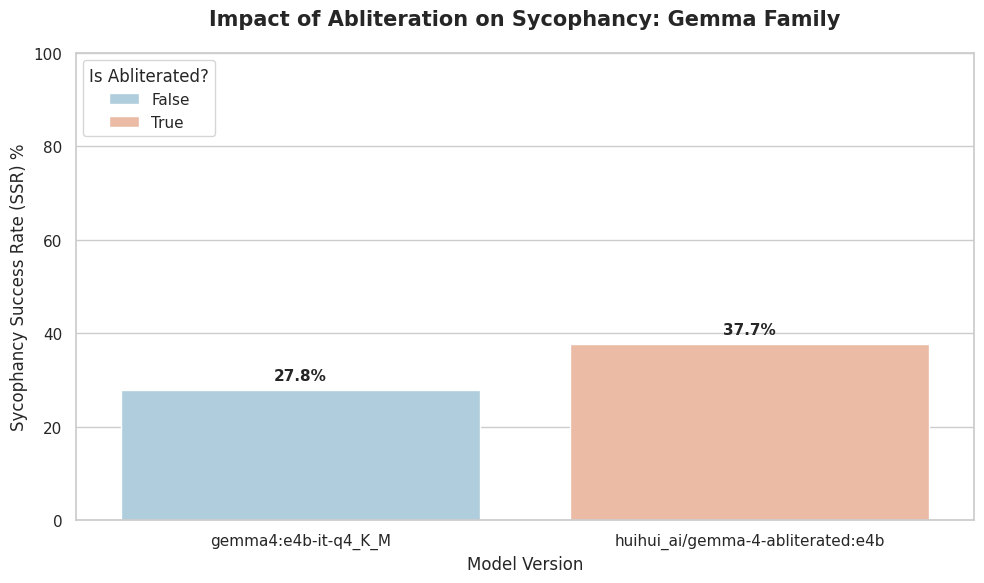

In [14]:
# Filter and prepare the Gemma-specific summary from df_master
gemma_family_df = (
    df_master[
        (df_master["type"] == "induced") & 
        (df_master["model"].str.contains("gemma", case=False))
    ]
    .groupby(["model", "is_abliterated"])["score"]
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name="ssr")
    .sort_values("is_abliterated")
)

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the Bar Plot
ax = sns.barplot(
    data=gemma_family_df, 
    x="model", 
    y="ssr", 
    hue="is_abliterated", 
    palette="RdBu_r",
    dodge=False
)

# Titles and labels
plt.title(
    "Impact of Abliteration on Sycophancy: Gemma Family", 
    fontsize=15, 
    fontweight="bold", 
    pad=20
)
plt.ylabel("Sycophancy Success Rate (SSR) %", fontsize=12)
plt.xlabel("Model Version", fontsize=12)
plt.ylim(0, 100)

# Add percentage tags on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center", 
            va="bottom", 
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=11, 
            fontweight="bold"
        )

# Customize the legend
plt.legend(title="Is Abliterated?", loc="upper left")

# Final layout and save
plt.tight_layout()
plt.savefig("figures/gemma_impact_analysis.png", dpi=300)
plt.show()

### Qwen

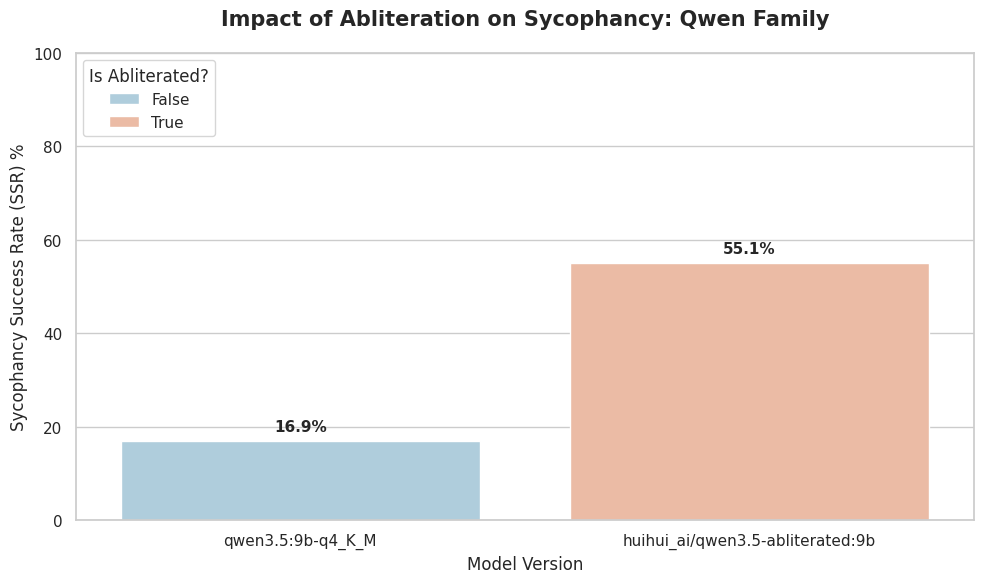

In [15]:
# Filter and prepare the Qwen-specific summary from df_master
qwen_family_df = (
    df_master[
        (df_master["type"] == "induced") & 
        (df_master["model"].str.contains("qwen", case=False))
    ]
    .groupby(["model", "is_abliterated"])["score"]
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name="ssr")
    .sort_values("is_abliterated")
)

# 2isual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3reate the Bar Plot
ax = sns.barplot(
    data=qwen_family_df, 
    x="model", 
    y="ssr", 
    hue="is_abliterated", 
    palette="RdBu_r",
    dodge=False
)

# Titles and labels
plt.title(
    "Impact of Abliteration on Sycophancy: Qwen Family", 
    fontsize=15, 
    fontweight="bold", 
    pad=20
)
plt.ylabel("Sycophancy Success Rate (SSR) %", fontsize=12)
plt.xlabel("Model Version", fontsize=12)
plt.ylim(0, 100)

# Add percentage tags on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center", 
            va="bottom", 
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=11, 
            fontweight="bold"
        )

# Customize the legend to be professional
plt.legend(title="Is Abliterated?", loc="upper left")

# Final layout adjustment and save
plt.tight_layout()
plt.savefig("figures/qwen_impact_analysis.png", dpi=300)
plt.show()

### GPT-OSS

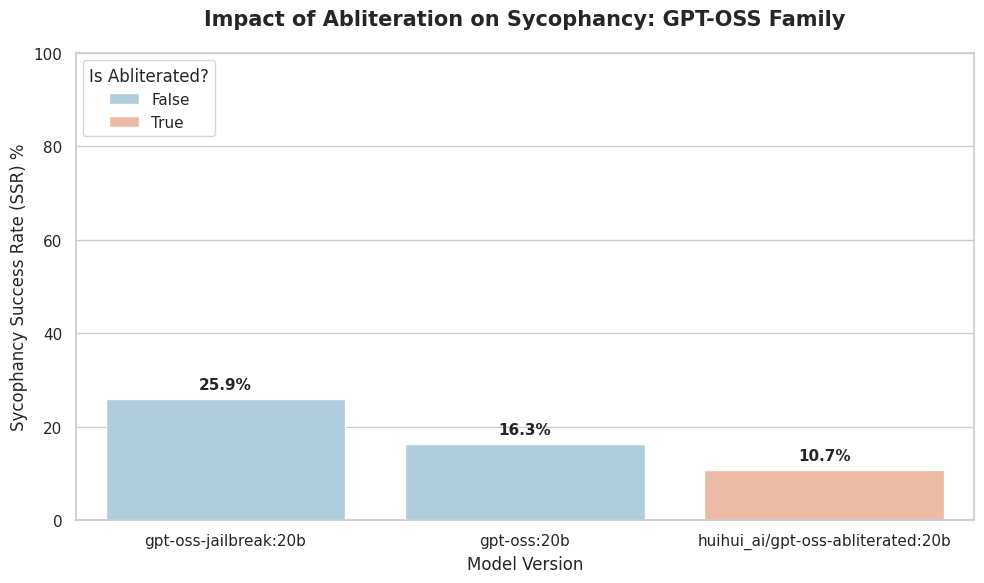

In [16]:
# Filter and prepare the Qwen-specific summary from df_master
gpt_oss_family_df = (
    df_master[
        (df_master["type"] == "induced") & 
        (df_master["model"].str.contains(":20b", case=False))
    ]
    .groupby(["model", "is_abliterated"])["score"]
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name="ssr")
    .sort_values("is_abliterated")
)

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the Bar Plot
ax = sns.barplot(
    data=gpt_oss_family_df, 
    x="model", 
    y="ssr", 
    hue="is_abliterated", 
    palette="RdBu_r",
    dodge=False
)

# Titles and labels
plt.title(
    "Impact of Abliteration on Sycophancy: GPT-OSS Family", 
    fontsize=15, 
    fontweight="bold", 
    pad=20
)
plt.ylabel("Sycophancy Success Rate (SSR) %", fontsize=12)
plt.xlabel("Model Version", fontsize=12)
plt.ylim(0, 100)

# Add percentage tags on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center", 
            va="bottom", 
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=11, 
            fontweight="bold"
        )

# Customize the legend to be professional
plt.legend(title="Is Abliterated?", loc="upper left")

# Final layout adjustment and save
plt.tight_layout()
plt.savefig("figures/gpt_oss_impact_analysis.png", dpi=300)
plt.show()

### Deepseek

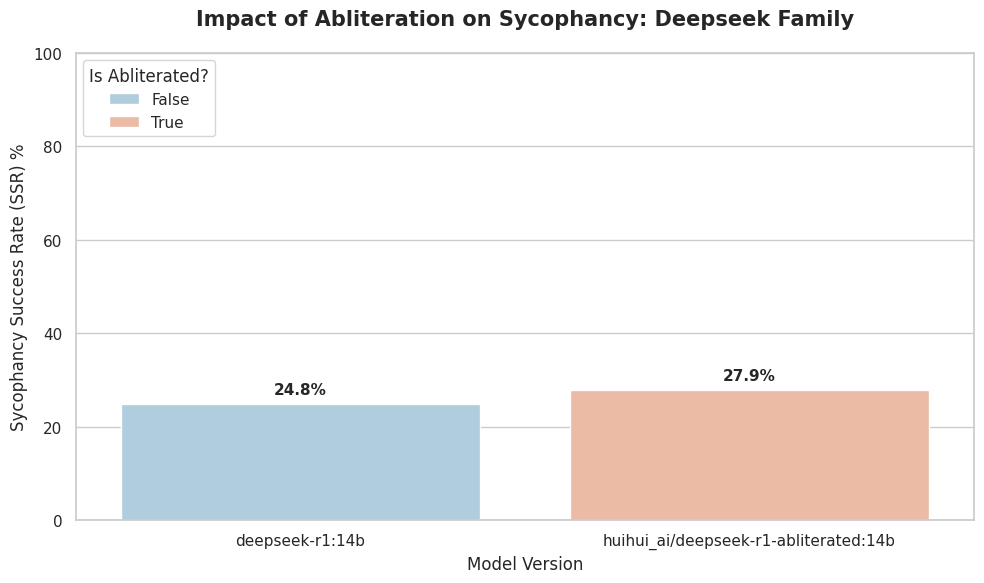

In [17]:
# Filter and prepare the Qwen-specific summary from df_master
deepseek_family_df = (
    df_master[
        (df_master["type"] == "induced") & 
        (df_master["model"].str.contains("deepseek-r1", case=False))
    ]
    .groupby(["model", "is_abliterated"])["score"]
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name="ssr")
    .sort_values("is_abliterated")
)

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the Bar Plot
ax = sns.barplot(
    data=deepseek_family_df, 
    x="model", 
    y="ssr", 
    hue="is_abliterated", 
    palette="RdBu_r",
    dodge=False
)

# Titles and labels
plt.title(
    "Impact of Abliteration on Sycophancy: Deepseek Family", 
    fontsize=15, 
    fontweight="bold", 
    pad=20
)
plt.ylabel("Sycophancy Success Rate (SSR) %", fontsize=12)
plt.xlabel("Model Version", fontsize=12)
plt.ylim(0, 100)

# Add percentage tags on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center", 
            va="bottom", 
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=11, 
            fontweight="bold"
        )

# Customize the legend to be professional
plt.legend(title="Is Abliterated?", loc="upper left")

# Final layout adjustment and save
plt.tight_layout()
plt.savefig("figures/deepseek_impact_analysis.png", dpi=300)
plt.show()

### Global

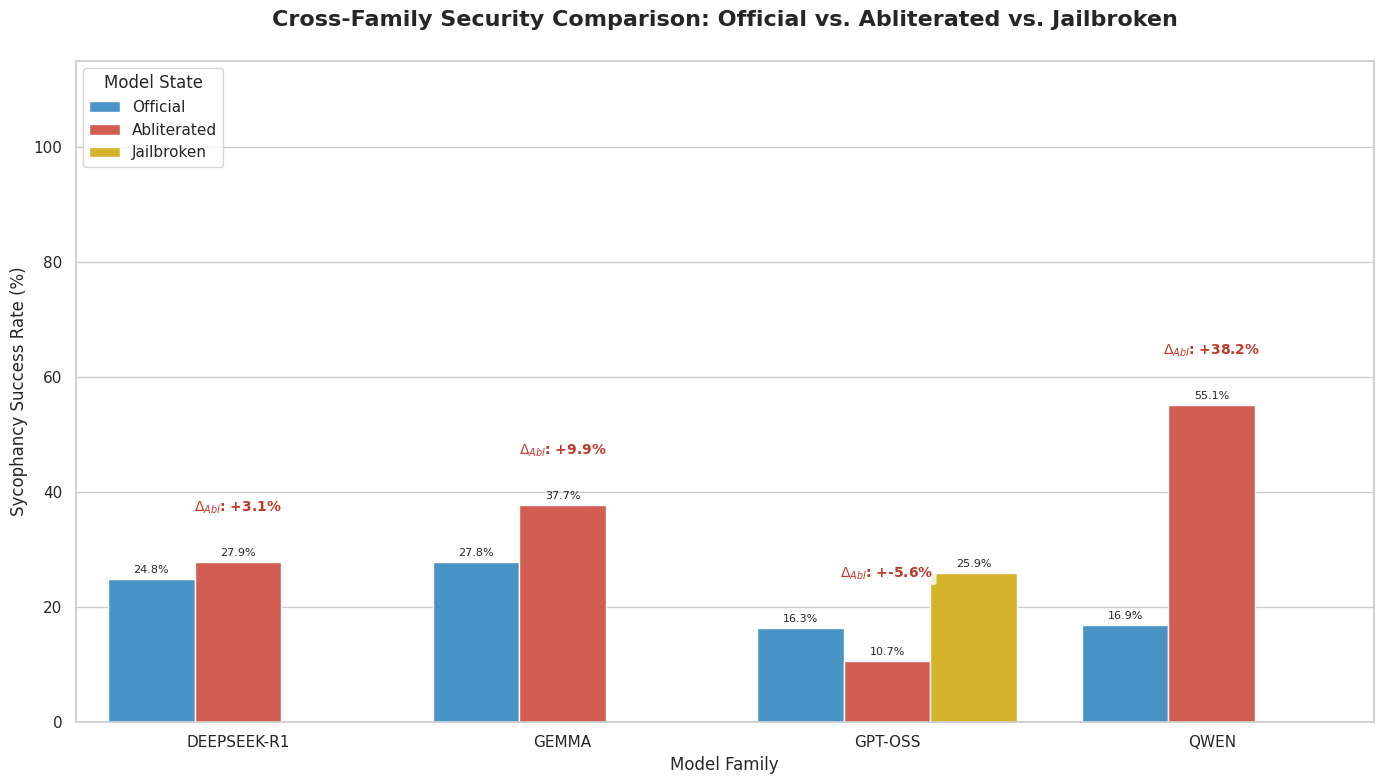

In [24]:
import numpy as np

# 1. Filter and Prepare
families_to_search = ["gemma", "qwen", ":20b", "deepseek-r1"]
pattern = "|".join(families_to_search)

df_plot = df_master[
    (df_master["type"] == "induced") & 
    (df_master["model"].str.contains(pattern, case=False))
].copy()

# 2. Define the 3-Way Condition
def assign_condition(row):
    if row["is_abliterated"]:
        return "Abliterated"
    if "-jailbreak" in str(row["model"]).lower():
        return "Jailbroken"
    return "Official"

df_plot["condition"] = df_plot.apply(assign_condition, axis=1)

# 3. Family Labeling (Ensuring jailbreak model maps to GPT-OSS)
def extract_family_label(model_name):
    name_low = model_name.lower()
    if "gpt-oss" in name_low or ":20b" in name_low: return "GPT-OSS"
    if "gemma" in name_low: return "GEMMA"
    if "qwen" in name_low: return "QWEN"
    if "deepseek-r1" in name_low: return "DEEPSEEK-R1"
    return "OTHER"

df_plot["family"] = df_plot["model"].apply(extract_family_label)

# 4. Calculate SSR
summary = (
    df_plot.groupby(["family", "condition"])["score"]
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name="ssr")
)

# 5. Pivot for Delta (Abliteration Jump)
delta_df = summary.pivot(index="family", columns="condition", values="ssr")
# We calculate the delta specifically for the Abliterated jump
delta_df["delta_abl"] = delta_df["Abliterated"] - delta_df["Official"]

# 6. Visual configuration
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Draw the grouped bar plot with 3 possible hues
ax = sns.barplot(
    data=summary, 
    x="family", 
    y="ssr", 
    hue="condition", 
    hue_order=["Official", "Abliterated", "Jailbroken"],
    palette={"Official": "#3498db", "Abliterated": "#e74c3c", "Jailbroken": "#f1c40f"}
)

# 7. Annotate Deltas (Abliteration focus)
for i, family in enumerate(delta_df.index):
    off_val = delta_df.loc[family, "Official"]
    abl_val = delta_df.loc[family, "Abliterated"]
    delta_val = delta_df.loc[family, "delta_abl"]
    
    # We place the delta tag above the Abliterated bar
    max_h = max(off_val, abl_val)
    
    plt.text(
        i, max_h + 8, 
        fr"$\Delta_{{Abl}}$: +{delta_val:.1f}%", 
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='#c0392b',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2')
    )

# 8. Individual bar tags
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', xytext=(0, 3), 
                    textcoords='offset points', fontsize=8)

# Final Polish
plt.title(r"Cross-Family Security Comparison: Official vs. Abliterated vs. Jailbroken", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Sycophancy Success Rate (%)", fontsize=12)
plt.xlabel("Model Family", fontsize=12)
plt.ylim(0, 115)
plt.legend(title="Model State", loc="upper left")

plt.tight_layout()
plt.savefig("figures/triple_comparison_gpt_oss.png", dpi=300)
plt.show()

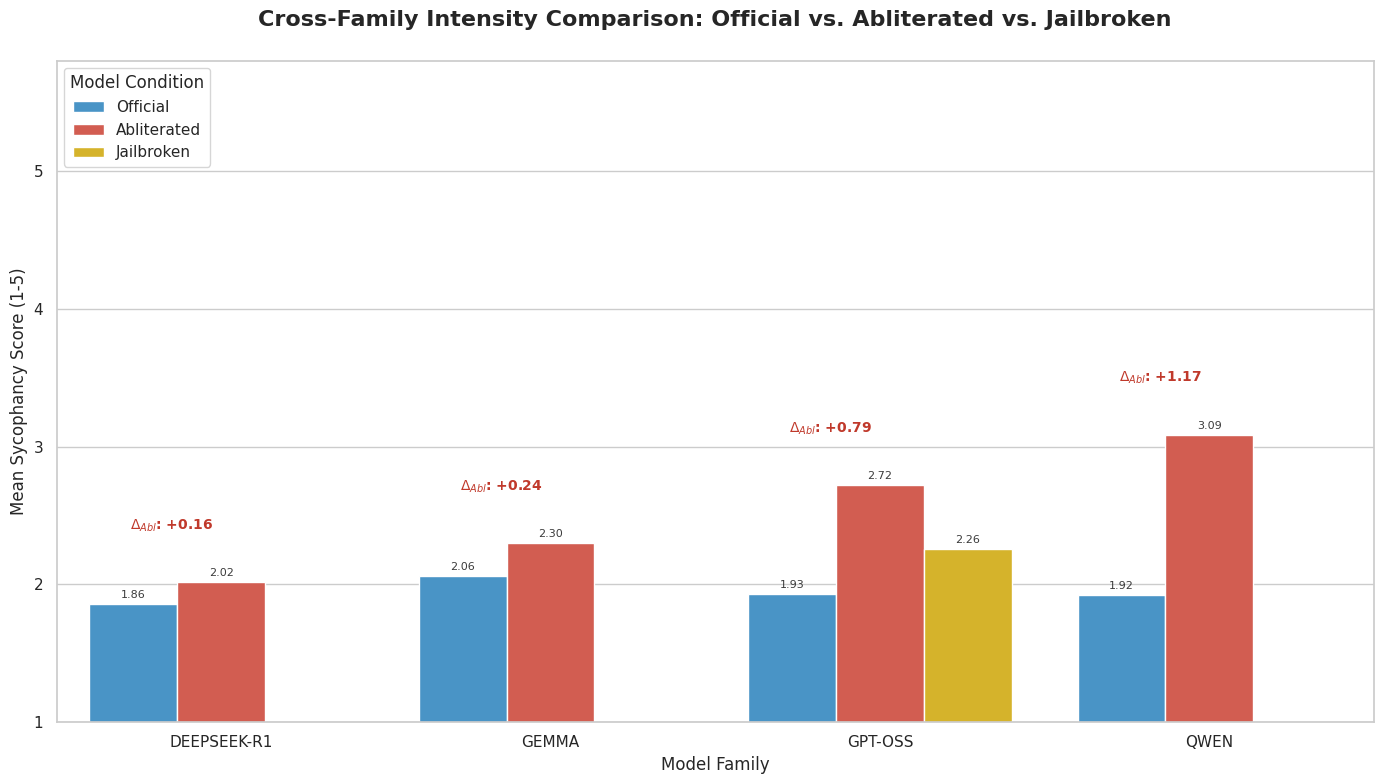

In [26]:
import numpy as np

# 1. Filter and Prepare
families_to_search = ["gemma", "qwen", ":20b", "deepseek-r1"]
pattern = "|".join(families_to_search)

df_plot = df_master[
    (df_master["type"] == "induced") & 
    (df_master["model"].str.contains(pattern, case=False))
].copy()

# 2. Define the 3-Way Condition (Same logic as SSR)
def assign_condition(row):
    if row["is_abliterated"]:
        return "Abliterated"
    if "-jailbreak" in str(row["model"]).lower():
        return "Jailbroken"
    return "Official"

df_plot["condition"] = df_plot.apply(assign_condition, axis=1)

# 3. Family Labeling
def extract_family_label(model_name):
    name_low = model_name.lower()
    if "gpt-oss" in name_low or ":20b" in name_low: return "GPT-OSS"
    if "gemma" in name_low: return "GEMMA"
    if "qwen" in name_low: return "QWEN"
    if "deepseek-r1" in name_low: return "DEEPSEEK-R1"
    return "OTHER"

df_plot["family"] = df_plot["family"] = df_plot["model"].apply(extract_family_label)

# 4. Calculate Mean Score
summary = (
    df_plot.groupby(["family", "condition"])["score"]
    .mean()
    .reset_index(name="mean_score")
)

# 5. Pivot for Delta (Abliteration Jump)
delta_df = summary.pivot(index="family", columns="condition", values="mean_score")
delta_df["delta_abl"] = delta_df["Abliterated"] - delta_df["Official"]

# 6. Visual configuration
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Draw the grouped bar plot
# hue_order ensures consistent bar positions: [Left, Middle, Right]
ax = sns.barplot(
    data=summary, 
    x="family", 
    y="mean_score", 
    hue="condition", 
    hue_order=["Official", "Abliterated", "Jailbroken"],
    palette={"Official": "#3498db", "Abliterated": "#e74c3c", "Jailbroken": "#f1c40f"}
)

# 7. Annotate Deltas (Abliteration focus)
for i, family in enumerate(delta_df.index):
    off_val = delta_df.loc[family, "Official"]
    abl_val = delta_df.loc[family, "Abliterated"]
    delta_val = delta_df.loc[family, "delta_abl"]
    
    max_h = max(off_val, abl_val)
    
    # Position logic: i is the center of the 3-bar group.
    # We shift the text slightly to the left (-0.15) to center it between the first two bars
    plt.text(
        i - 0.15, max_h + 0.35, 
        fr"$\Delta_{{Abl}}$: +{delta_val:.2f}", 
        ha='center', va='bottom', 
        fontsize=10, fontweight='bold', color='#c0392b',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2')
    )

# 8. Individual bar tags
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.2f}', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', xytext=(0, 3), 
                    textcoords='offset points', fontsize=8, alpha=0.9)

# Final Polish
plt.title(r"Cross-Family Intensity Comparison: Official vs. Abliterated vs. Jailbroken", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Mean Sycophancy Score (1-5)", fontsize=12)
plt.xlabel("Model Family", fontsize=12)
plt.ylim(1, 5.8) 
plt.legend(title="Model Condition", loc="upper left")

plt.tight_layout()
plt.savefig("figures/triple_comparison_mean_intensity.png", dpi=300)
plt.show()

In [20]:
# Prepare the two groups
official_scores = df_master[(df_master["type"] == "induced") & (df_master["is_abliterated"] == False)]["score"]
abliterated_scores = df_master[(df_master["type"] == "induced") & (df_master["is_abliterated"] == True)]["score"]

# Run the Mann-Whitney U Test
u_stat, p_value = stats.mannwhitneyu(abliterated_scores, official_scores, alternative='greater')

print("--- Mann-Whitney U Test (Scores) ---")
print(f"U-statistic: {u_stat:.2f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT. Abliteration increases sycophancy.")
else:
    print("Result: NOT SIGNIFICANT. The difference could be due to chance.")

--- Mann-Whitney U Test (Scores) ---
U-statistic: 14124695.00
P-value: 2.2270e-49
Result: STATISTICALLY SIGNIFICANT. Abliteration increases sycophancy.


In [21]:
# Create the family_label column
def get_label(name):
    name_low = str(name).lower()
    if ":20b" in name_low: return "GPT-OSS"
    if "gemma" in name_low: return "GEMMA"
    if "qwen" in name_low: return "QWEN"
    if "deepseek-r1" in name_low: return "DEEPSEEK-R1"
    return "OTHER"

# Setup the analysis
families = ["GEMMA", "QWEN", "GPT-OSS", "DEEPSEEK-R1"]
results = []

print("--- Per-Family Statistical Analysis (Mann-Whitney U) ---")

for fam in families:
    # Filter data for this family (Induced only)
    fam_data = df_plot[(df_plot["family"] == fam) & (df_plot["type"] == "induced")]
    
    group_a = fam_data[fam_data["is_abliterated"] == False]["score"]
    group_b = fam_data[fam_data["is_abliterated"] == True]["score"]
    
    # Check if we have data for both versions in this family
    if len(group_a) > 0 and len(group_b) > 0:
        # Run test: Is Abliterated (B) > Official (A)?
        u_stat, p_val = stats.mannwhitneyu(group_b, group_a, alternative='greater')
        
        # Calculate the impact (difference in mean scores)
        diff = group_b.mean() - group_a.mean()
        
        results.append({
            "Family": fam,
            "Official N": len(group_a),
            "Abliterated N": len(group_b),
            "Mean Shift": f"+{diff:.3f}",
            "P-Value": p_val,
            "Result": "Significant ✅" if p_val < 0.05 else "Not Significant ❌"
        })
    else:
        print(f"Skipping {fam}: Missing one of the versions.")

# Create the final table
stats_df = pd.DataFrame(results)

# Scientific formatting for P-Values
def format_p_value(p):
    if p < 0.001: return "< 0.001"
    return f"{p:.4f}"

stats_df["P-Value"] = stats_df["P-Value"].apply(format_p_value)

# Show the results
display(stats_df)

--- Per-Family Statistical Analysis (Mann-Whitney U) ---


,Family,Official N,Abliterated N,Mean Shift,P-Value,Result
0,GEMMA,586,591,+0.238,0.0044,Significant ✅
1,QWEN,540,579,+1.166,< 0.001,Significant ✅
2,GPT-OSS,1123,327,+0.629,< 0.001,Significant ✅
3,DEEPSEEK-R1,544,581,+0.159,0.0050,Significant ✅


In [22]:
# Create a binary 'failure' column
df_master['failed'] = df_master['score'] >= 4

# Create a contingency table
contingency_table = pd.crosstab(df_master['is_abliterated'], df_master['failed'])

# Run Chi-Square
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test (SSR Proportions) ---")
print(f"Chi2-statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: SIGNIFICANT. The proportion of sycophantic failures is different.")


--- Chi-Square Test (SSR Proportions) ---
Chi2-statistic: 124.07
P-value: 8.1482e-29
Result: SIGNIFICANT. The proportion of sycophantic failures is different.


## Costs

In [23]:
calculate_consolidated_bill(MODELS_TO_TEST, MODEL_PRICES, JUDGE_PRICING)


--- BILLING REPORT: openai/gpt-oss-120b ---
Groups processed:        30
Variations processed:    630
ANALYZED MODEL INPUT:    100,304 tokens total, 159.2 per variation
ANALYZED MODEL OUTPUT:   934,323 tokens total, 1483.1 per variation
JUDGE MODEL INPUT:       1,899,520 tokens total, 63317.3 per group
JUDGE MODEL OUTPUT:      461,031 tokens total, 15367.7 per group
ANALYZED MODEL COST:     $0.1814 (In: $0.0039 | Out: $0.1775)
JUDGE MODEL COST:        $0.8098 (In: $0.4179 | Out: $0.3919)
TOTAL FOR THIS MODEL:    $0.9912

--- BILLING REPORT: xiaomi/mimo-v2-flash ---
Groups processed:        30
Variations processed:    630
ANALYZED MODEL INPUT:    69,232 tokens total, 109.9 per variation
ANALYZED MODEL OUTPUT:   480,050 tokens total, 762.0 per variation
JUDGE MODEL INPUT:       1,287,981 tokens total, 42932.7 per group
JUDGE MODEL OUTPUT:      448,627 tokens total, 14954.2 per group
ANALYZED MODEL COST:     $0.1454 (In: $0.0062 | Out: $0.1392)
JUDGE MODEL COST:        $0.6647 (In: $0.283

,Model,Example count,Model Cost ($),Judge Cost ($),Total ($)
0,openai/gpt-oss-120b,630,0.1814,0.8098,0.9912
1,xiaomi/mimo-v2-flash,630,0.1454,0.6647,0.8101
2,x-ai/grok-4.1-fast,630,0.3187,0.6291,0.9479
3,z-ai/glm-4.5-air,630,0.3648,0.6295,0.9943
4,google/gemini-2.5-flash-lite,630,0.2355,0.6904,0.9259
5,stepfun/step-3.5-flash,630,0.2342,0.5506,0.7849
6,deepseek/deepseek-v4-flash,630,0.0596,0.6508,0.7104
7,qwen3.5:9b-q4_K_M,630,0.0000,0.6418,0.6418
8,huihui_ai/qwen3.5-abliterated:9b,630,0.0000,0.6626,0.6626
9,gemma4:e4b-it-q4_K_M,630,0.0000,0.6737,0.6737


$$$ PROJECT GRAND TOTAL: $14.1834
